<a href="https://colab.research.google.com/github/2303A52393/Ex-AI/blob/main/EX_AI_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [4]:
try:
    import xgboost as xgb
    has_xgb = True
except Exception:
    has_xgb = False

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [6]:
import shap

In [8]:
try:
    import lime
    from lime import lime_tabular
    has_lime = True
except Exception:
    has_lime = False

In [9]:
import seaborn as sns
sns.set(style='whitegrid')

In [11]:
DATA_PATH = "co_emissions.csv"

In [13]:
if not os.path.exists(DATA_PATH):
    print(f"{DATA_PATH} not found. Please upload it.")
else:
    print(f"Using data from {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)
    print("Dataset loaded. Shape:", df.shape)
    display(df.head())

co_emissions.csv not found. Please upload it.


In [15]:
try:
    df_info = df.info()
except Exception:
    pass

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
# Load your CSV (update the path/filename)
df = pd.read_csv("/content/lung_cancer_dataset (1).csv")
# look at the first few rows
print(df.head())
print(df.columns)

   patient_id  age  gender  pack_years radon_exposure asbestos_exposure  \
0      100000   69    Male   66.025244           High                No   
1      100001   32  Female   12.780800           High                No   
2      100002   89  Female    0.408278         Medium               Yes   
3      100003   78  Female   44.065232            Low                No   
4      100004   38  Female   44.432440         Medium               Yes   

  secondhand_smoke_exposure copd_diagnosis alcohol_consumption family_history  \
0                        No            Yes            Moderate             No   
1                       Yes            Yes            Moderate            Yes   
2                       Yes            Yes                 NaN             No   
3                       Yes             No            Moderate             No   
4                        No            Yes                 NaN            Yes   

  lung_cancer  
0          No  
1         Yes  
2         Yes 

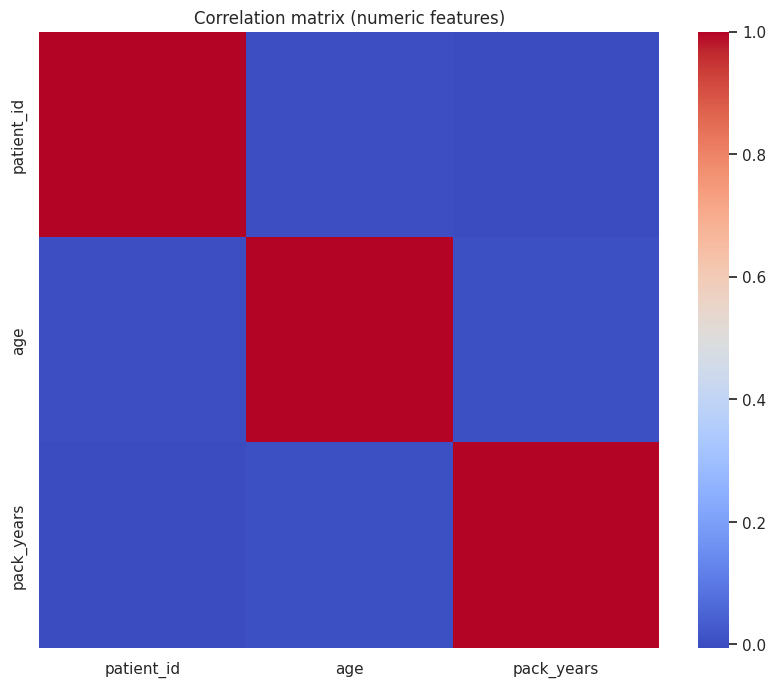

In [19]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=False, cmap='coolwarm')
    plt.title('Correlation matrix (numeric features)')
    plt.show()

In [23]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
# Define target_col before using it
if 'CO2_emissions' in df.columns:
    target_col = 'CO2_emissions'
else:
    # try searching for plausible target columns
    candidates = [c for c in df.columns if 'co2' in c.lower() or 'emiss' in c.lower()]
    target_col = candidates[0] if candidates else df.columns[-1]
    print('Auto-selected target column:', target_col)

num_cols = [c for c in df.select_dtypes(include=[np.number]).columns.tolist()
            if c != target_col]

Auto-selected target column: lung_cancer


In [24]:
print('Categorical columns:', cat_cols)
print('Numerical columns:', num_cols)

Categorical columns: ['gender', 'radon_exposure', 'asbestos_exposure', 'secondhand_smoke_exposure', 'copd_diagnosis', 'alcohol_consumption', 'family_history', 'lung_cancer']
Numerical columns: ['patient_id', 'age', 'pack_years']


In [27]:
if 'population' in df.columns:
    df['co2_per_capita'] = df[target_col] / (df['population'].replace({0: np.nan}))
    num_cols.append('co2_per_capita')

In [29]:
for col in num_cols:
    if (df[col] > 0).all() and df[col].skew() > 1:
        df[col + '_log'] = np.log1p(df[col])
        num_cols.append(col + '_log')

In [30]:
numeric_transformer = Pipeline(steps=[
('imputer', SimpleImputer(strategy='median')),
('scaler', StandardScaler())
])

In [31]:
categorical_transformer = Pipeline(steps=[
('imputer', SimpleImputer(strategy='most_frequent')),
('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [32]:
preprocessor = ColumnTransformer(
transformers=[
('num', numeric_transformer, num_cols),
('cat', categorical_transformer, cat_cols)
],
remainder='drop'
)

In [33]:
all_cols = num_cols + cat_cols
unique_cols = list(set(all_cols))
X = df[unique_cols].copy()
y = df[target_col].copy()

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
try:
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
except Exception:
    cat_feature_names = []
all_feature_names = num_cols + cat_feature_names
feature_names = list(set(all_feature_names))

In [38]:
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print('Processed train shape:', X_train_proc.shape)

Processed train shape: (26267, 21)


In [40]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR()
}

In [42]:
if has_xgb:
    models['XGBoost'] = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)

In [46]:
def build_mlp(input_dim):
    model = tf.keras.models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [48]:
def to_seq(X):
    return X.reshape((X.shape[0], X.shape[1], 1))

In [51]:
X_train_seq = to_seq(X_train_proc)
X_test_seq = to_seq(X_test_proc)

In [52]:
cnn = tf.keras.models.Sequential([
layers.Input(shape=(X_train_seq.shape[1], 1)),
layers.Conv1D(64, kernel_size=3, activation='relu'),
layers.Conv1D(32, kernel_size=3, activation='relu'),
layers.Flatten(),
layers.Dense(1, activation='linear')
])

In [56]:
rf = models['RandomForest']
try:
    importances = rf.feature_importances_
    fi = pd.Series(importances, index=feature_names)
    fi_sorted = fi.sort_values(ascending=False).head(20)
    plt.figure(figsize=(8,6))
    fi_sorted.plot(kind='bar')
    plt.title('Random Forest Top Feature Importances')
    plt.show()
except Exception as e:
    print('Could not compute feature importances:', e)

Could not compute feature importances: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


In [58]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
if len(feature_names) >= 1:
    feat_idx = 0 # change to a meaningful feature index (e.g., index of 'coal' usage)
    try:
        display = PartialDependenceDisplay.from_estimator(rf, X_test_proc, [feat_idx], feature_names=feature_names)
        # Display the plot
        display.figure_.suptitle(f"Partial Dependence Plot for Feature: {feature_names[feat_idx]}")
        plt.show()
    except Exception as e:
        print('PDP failed:', e)

PDP failed: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


In [59]:
cnn_preds = cnn.predict(X_test_seq).flatten()

206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
